Example of Central Limit Theorem
==
(Convergence of Sample Mean distribution to normal)
==

Here we give an example of a distribution which is asymetric and clearly not normal to start with, yet when "sampling of the sample mean" given a sample size n=10, 100, 1000 are taken, the distribution of the sample mean can be seen  converging to a normal distribution. 

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import random
import math

In [2]:
np.random.seed(17)
first_distribution = stats.norm(-1000,200).rvs(size=100000)
second_distribution = stats.norm(2,500).rvs(size=100000)
combined_norm = np.concatenate((first_distribution, second_distribution))
print(combined_norm.mean())
print(len(combined_norm))

-498.25241607500703
200000


0.6299032295984425


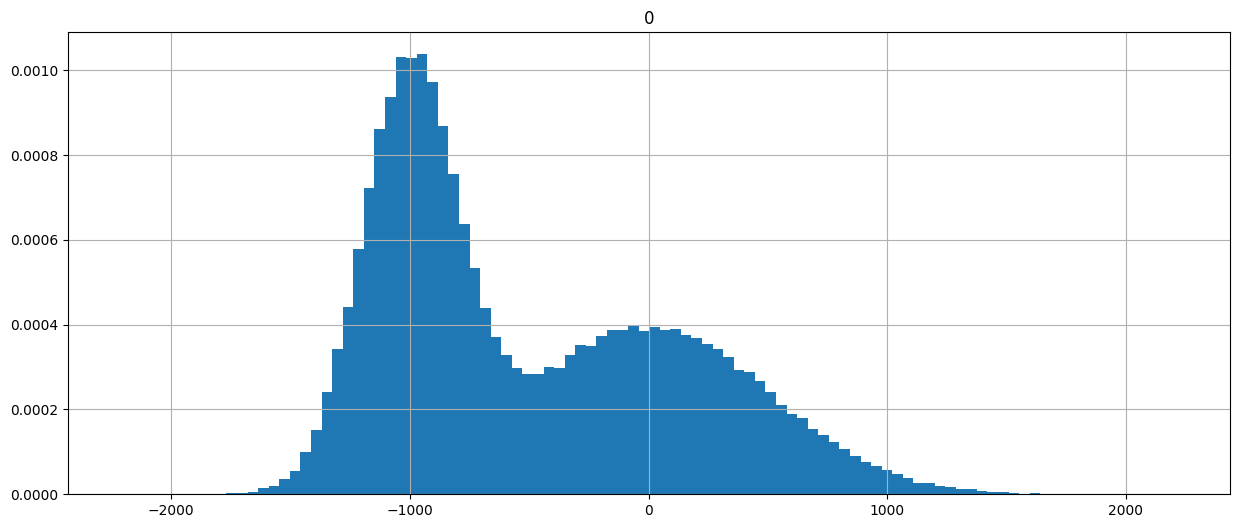

In [3]:
pd.DataFrame(combined_norm).hist(bins=100,figsize=(15,6), density=True)
print(stats.skew(combined_norm))

In [4]:
np.random.seed(19)
sample_10 = np.random.choice(a= combined_norm,size=10) 
sample_100 = np.random.choice(a= combined_norm,size=100)  
sample_1000 = np.random.choice(a= combined_norm,size=1000)

#How close are the sample means to the actual pop mean?

print(combined_norm.mean() - sample_10.mean())
print(combined_norm.mean() - sample_100.mean())
print(combined_norm.mean() - sample_1000.mean())

-84.13964638615943
-39.73005710049284
15.72500406164255


In [5]:
np.random.seed(15)

my_estimator_10 = []         
my_estimator_100 = []         
my_estimator_1000 = []         

for x in range(500):         # Generate 500 samples
    sample10 = np.random.choice(a= combined_norm, size=10) # Sample size n = 10 
    sample100 = np.random.choice(a= combined_norm, size=100) # Sample size n = 100
    sample1000 = np.random.choice(a= combined_norm, size=1000) # Sample size n = 1000
    my_estimator_10.append( sample10.mean() )
    my_estimator_100.append( sample100.mean() )
    my_estimator_1000.append( sample1000.mean() )
    

In [6]:
df=pd.DataFrame({'N10':my_estimator_10,'N100':my_estimator_100,'N1000':my_estimator_1000})

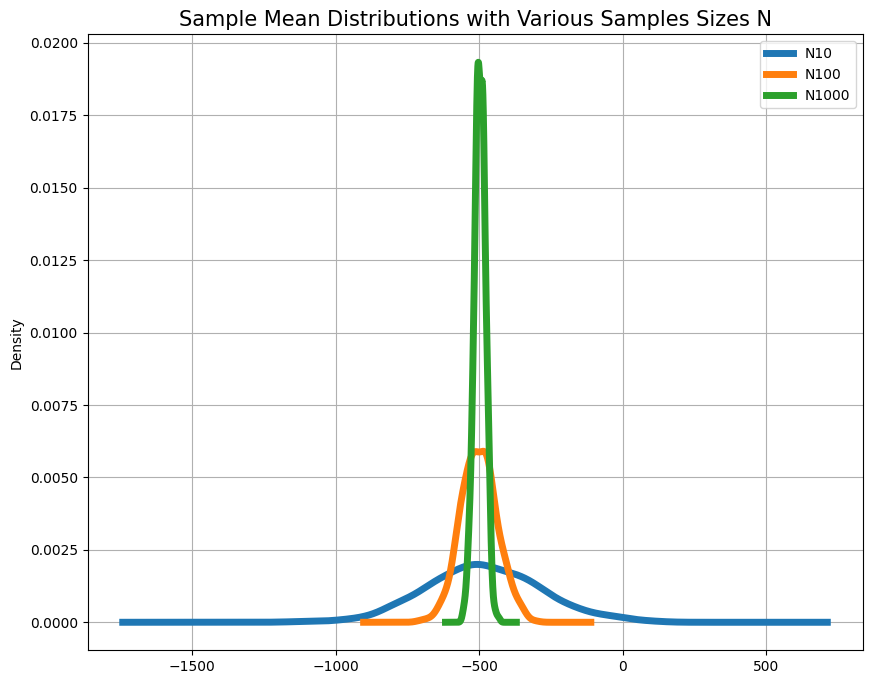

In [7]:
df.plot(kind='density',grid=True,figsize=(10,8), linewidth=5 )
plt.title("Sample Mean Distributions with Various Samples Sizes N",size=15);

In [8]:
snd = stats.norm(0,1).rvs(size=1000000)
np.quantile(snd,0.75)

0.6735726684579109

In [9]:
np.random.seed(17)
first_distribution = stats.geom(0.2).rvs(size=100000)
second_distribution = stats.binom(10,0.6).rvs(size=100000)
combined_dist = np.concatenate((first_distribution, second_distribution))
print(combined_dist.mean())
print(len(combined_dist))

5.4958
200000


2.004435977381031


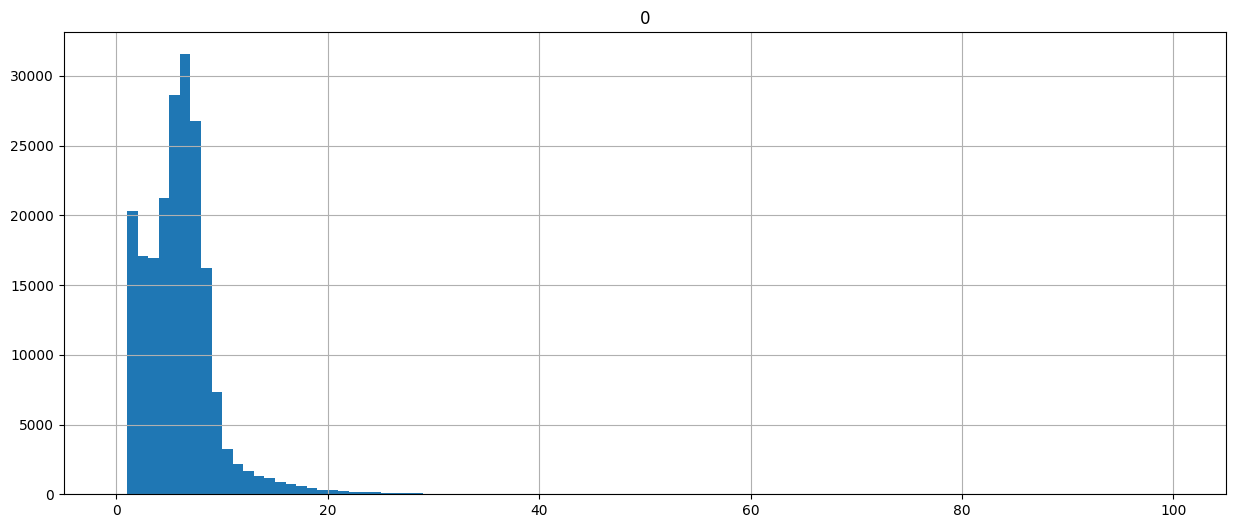

In [10]:
pd.DataFrame(combined_dist).hist(bins=100,range=(0,100),figsize=(15,6))
print(stats.skew(combined_dist))

In [11]:
np.random.seed(19)
sample_10 = np.random.choice(a= combined_dist,size=10) 
sample_100 = np.random.choice(a= combined_dist,size=100)  
sample_1000 = np.random.choice(a= combined_dist,size=1000)

#How close are the sample means to the actual pop mean?

print(combined_dist.mean() - sample_10.mean())
print(combined_dist.mean() - sample_100.mean())
print(combined_dist.mean() - sample_1000.mean())

-1.1041999999999996
-0.5541999999999998
0.08180000000000032


In [12]:
np.random.seed(15)

my_estimator_10 = []         
my_estimator_50 = []         
my_estimator_100 = []         

for x in range(100):         # Generate 100 samples
    sample10 = np.random.choice(a= combined_dist, size=10)
    sample50 = np.random.choice(a= combined_dist, size=50)
    sample100 = np.random.choice(a= combined_dist, size=100)
    my_estimator_10.append( sample10.mean() )
    my_estimator_50.append( sample50.mean() )
    my_estimator_100.append( sample100.mean() )
    

In [13]:
df=pd.DataFrame({'N10':my_estimator_10,'N50':my_estimator_50,'N100':my_estimator_100})
df.head()

,N10,N50,N100
0,4.4,5.48,5.66
1,3.9,6.36,5.27
2,4.8,5.42,5.39
3,3.0,5.58,4.99
4,5.3,5.36,5.23


Text(0.5, 1.0, 'Sample Mean Distributions - Geometric X')

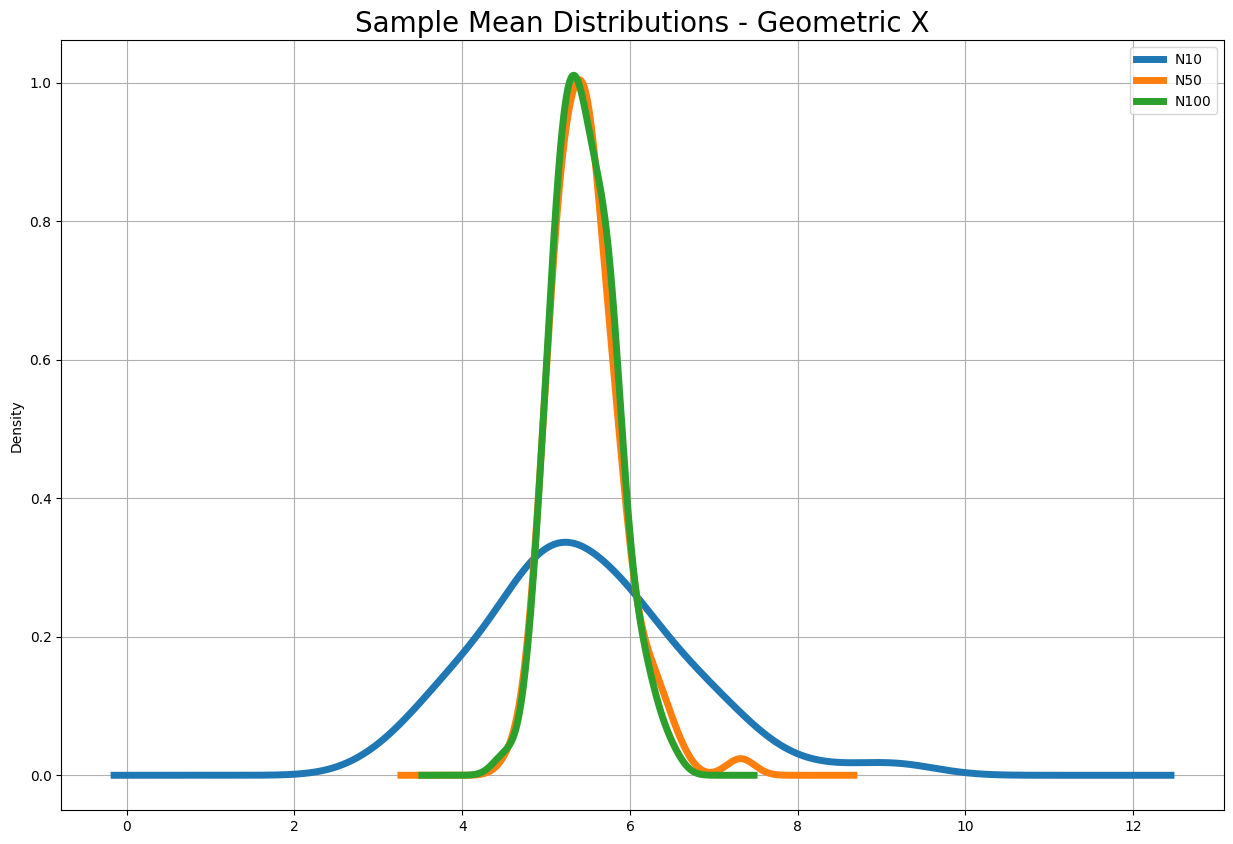

In [14]:
df.plot(kind='density',grid=True,figsize=(15,10), linewidth=5 )
plt.title("Sample Mean Distributions - Geometric X",size=20)